In [1]:
import pandas as pd
import numpy as np 
import sklearn as sk
import matplotlib.pyplot as plt
import statsmodels.api as sm

Form GBM model

In [18]:
x_train = pd.read_csv('../data/x_train_cluster_agglom.csv')
y_train = pd.read_csv('../data/y_train.csv')
x_test = pd.read_csv('../data/x_test_cluster_agglom.csv')
y_test = pd.read_csv('../data/y_test.csv')

gbm = sk.ensemble.GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=0, min_samples_leaf=20)
gbm.fit(x_train, y_train.values.ravel())

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

Evaluate accuracy by finding misclassification rate and percent area under ROC curve

Misclassification Rate: 25.97%
AUC-ROC: 81.81%
Misclassification Rate: 26.30%
AUC-ROC: 81.22%


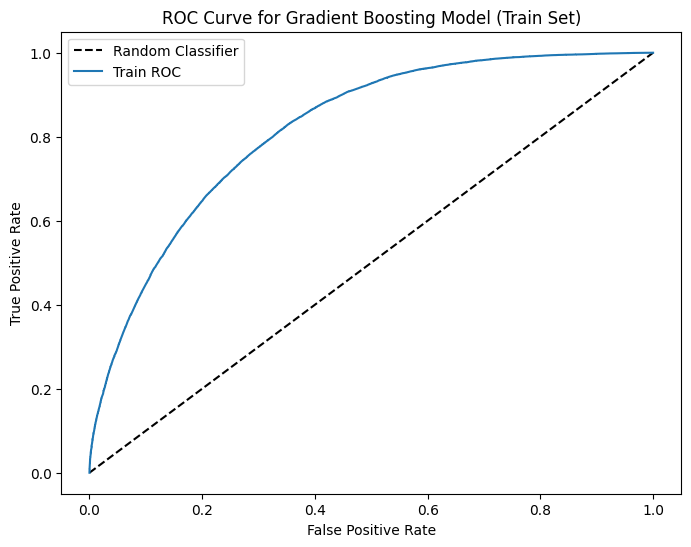

In [19]:
conf_matrix_train = sk.metrics.confusion_matrix(y_train, gbm.predict(x_train) > 0.5)

misclassify_rate_train = (conf_matrix_train[0][1] + conf_matrix_train[1][0]) / len(y_train)

print(f"Misclassification Rate: {misclassify_rate_train:.2%}")

auc_roc_train = sk.metrics.roc_auc_score(y_train, gbm.predict_proba(x_train)[:, 1])
print(f"AUC-ROC: {auc_roc_train:.2%}")

conf_matrix_test = sk.metrics.confusion_matrix(y_test, gbm.predict(x_test) > 0.5)

misclassify_rate_test = (conf_matrix_test[0][1] + conf_matrix_test[1][0]) / len(y_test)

print(f"Misclassification Rate: {misclassify_rate_test:.2%}")

auc_roc_test = sk.metrics.roc_auc_score(y_test, gbm.predict_proba(x_test)[:, 1])
print(f"AUC-ROC: {auc_roc_test:.2%}")

# Plot ROC curve for training set

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
fpr_train, tpr_train, _ = sk.metrics.roc_curve(y_train, gbm.predict_proba(x_train)[:, 1])
plt.plot(fpr_train, tpr_train, label="Train ROC")
plt.title("ROC Curve for Gradient Boosting Model (Train Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()